In [1]:
# Jalankan sel ini sekali untuk memasang pustaka yang dibutuhkan (boleh dilewati jika sudah terpasang).
# Jika setelah instalasi masih muncul ModuleNotFoundError, restart kernel lalu jalankan ulang dari atas.
%pip install -q geopandas sentinelhub folium seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\OKAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import os, math, time, getpass, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.raster_layers import ImageOverlay
from shapely.geometry import Point
from IPython.display import display, Markdown

from sentinelhub import (SHConfig, SentinelHubRequest, DataCollection, BBox, CRS,
                         MimeType, bbox_to_dimensions)

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score)

# ----------------- KONFIGURASI (SESUAIKAN) -----------------
DATA_DIR    = "."                                  # folder berisi shapefile
TANGGAL_MULAI, TANGGAL_AKHIR = "2025-01-01", "2025-12-31"   # periode citra
MAX_CLOUD   = 30                                   # maks. % awan per scene
HANYA_SENTINEL_2A = False                          # True: buang citra Sentinel-2B/2C
SEED        = 42                                   # agar hasil dapat direproduksi
CSV_DATASET = "dataset_sentinel2_jatim.csv"
ULANGI_EKSTRAKSI = False                           # True: paksa ambil ulang dari Copernicus
# ------------------------------------------------------------

# id : nama kelas, berkas shapefile, target sampel, warna peta
KELAS = {
    1: dict(nama="Sawah",                   file="sawah",       n=50, warna="#FFD92F"),
    2: dict(nama="Bangunan",                file="bangunan",    n=50, warna="#E41A1C"),
    3: dict(nama="Mangrove",                file="mangrove",    n=20, warna="#8E44AD"),
    4: dict(nama="Lahan Hijau",             file="lahan_hijau", n=20, warna="#2E7D32"),
    5: dict(nama="Perairan Terbuka (Laut)", file="lautan",      n=15, warna="#0D47A1"),
    6: dict(nama="Danau",                   file="danau",       n=20, warna="#4FC3F7"),
}
NAMA_KELAS  = [v["nama"] for v in KELAS.values()]
WARNA_KELAS = {v["nama"]: v["warna"] for v in KELAS.values()}
print("Jumlah kelas:", len(KELAS), "->", NAMA_KELAS)

Jumlah kelas: 6 -> ['Sawah', 'Bangunan', 'Mangrove', 'Lahan Hijau', 'Perairan Terbuka (Laut)', 'Danau']


In [3]:
def baca_shp(path):
    g = gpd.read_file(path)
    g = g.set_crs(4326) if g.crs is None else g.to_crs(4326)
    g = g[g.geometry.notnull() & ~g.geometry.is_empty].copy()
    g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else x.buffer(0))
    return g[["geometry"]].reset_index(drop=True)

def cari_shp(nama):
    """Mencari file <nama>.shp di DATA_DIR dan seluruh subfoldernya (spasi dan underscore dianggap sama)."""
    target = nama.lower().replace(" ", "_")
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if f.lower().endswith(".shp") and f[:-4].lower().replace(" ", "_") == target:
                return os.path.join(root, f)
    raise FileNotFoundError(f"File {nama}.shp tidak ditemukan di '{os.path.abspath(DATA_DIR)}' maupun subfoldernya.")

jalur_shp = {k: cari_shp(v["file"]) for k, v in KELAS.items()}
for k, p in jalur_shp.items():
    print(f"{KELAS[k]['nama']:<26} -> {p}")
poligon = {k: baca_shp(p) for k, p in jalur_shp.items()}

ringkas = []
for k, v in KELAS.items():
    g = poligon[k]
    luas_ha = g.to_crs(32749).area.sum() / 10_000      # UTM 49S, untuk luas dalam hektar
    b = g.total_bounds
    ringkas.append({"ID": k, "Kelas": v["nama"], "Jumlah poligon": len(g),
                    "Total luas (ha)": round(luas_ha, 1), "Target sampel": v["n"],
                    "BT min": round(b[0], 3), "LS min": round(b[1], 3),
                    "BT maks": round(b[2], 3), "LS maks": round(b[3], 3)})
display(pd.DataFrame(ringkas).set_index("ID"))

Sawah                      -> .\bangunan\sawah.shp
Bangunan                   -> .\sawah\bangunan.shp
Mangrove                   -> .\mangrove\mangrove.shp
Lahan Hijau                -> .\hutan_atau_lahan_hijau\lahan_hijau.shp
Perairan Terbuka (Laut)    -> .\lautan\lautan.shp
Danau                      -> .\danau\danau.shp


,Kelas,Jumlah poligon,Total luas (ha),Target sampel,BT min,LS min,BT maks,LS maks
ID,,,,,,,,
1,Sawah,51,6.1,50,112.601,-7.159,112.629,-7.149
2,Bangunan,62,44.7,50,112.605,-7.148,112.615,-7.139
3,Mangrove,20,138.4,20,112.659,-7.210,112.754,-7.010
4,Lahan Hijau,20,304446.1,20,111.688,-8.776,114.603,-7.353
5,Perairan Terbuka (Laut),15,940501.9,15,111.484,-8.458,114.062,-6.487
6,Danau,21,2036.8,20,111.539,-8.601,114.053,-7.097


In [4]:
rng = np.random.default_rng(SEED)

def titik_acak(poly, rng, maks=300):
    minx, miny, maxx, maxy = poly.bounds
    for _ in range(maks):
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if poly.contains(p):
            return p
    return poly.representative_point()

def ambil_sampel(gdf, n, rng):
    polys = list(gdf.geometry)
    urutan = rng.permutation(len(polys))
    hasil = []
    if len(polys) >= n:
        for i in urutan[:n]:
            hasil.append((polys[i].representative_point(), int(i)))
    else:
        for i in urutan:
            hasil.append((polys[i].representative_point(), int(i)))
        while len(hasil) < n:
            i = int(rng.integers(len(polys)))
            hasil.append((titik_acak(polys[i], rng), i))
    return hasil

baris = []
for k, v in KELAS.items():
    for p, pid in ambil_sampel(poligon[k], v["n"], rng):
        baris.append({"kelas_id": k, "kelas": v["nama"], "poligon_id": pid, "lon": p.x, "lat": p.y})
df_titik = pd.DataFrame(baris).reset_index(drop=True)
df_titik.index.name = "idx"
print("Total titik sampel:", len(df_titik))
display(df_titik["kelas"].value_counts().reindex(NAMA_KELAS).to_frame("jumlah titik"))

Total titik sampel: 175


,jumlah titik
kelas,
Sawah,50
Bangunan,50
Mangrove,20
Lahan Hijau,20
Perairan Terbuka (Laut),15
Danau,20


In [5]:
# ---------- Daftar fitur ----------
BAND_ASLI = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
INDEKS    = ["NDVI", "NDWI", "MNDWI", "NDBI", "NDRE", "EVI", "SAVI", "BSI"]
FITUR_SEMUA = BAND_ASLI + INDEKS

# ---------- Koneksi ke Copernicus Data Space Ecosystem ----------
_cache = {}
def buat_config():
    """Membuat konfigurasi Sentinel Hub untuk CDSE (kredensial diminta sekali saja)."""
    if "cfg" not in _cache:
        cfg = SHConfig()
        cfg.sh_client_id = os.environ.get("CDSE_CLIENT_ID") or input("Masukkan Client ID  : ").strip()
        cfg.sh_client_secret = os.environ.get("CDSE_CLIENT_SECRET") or getpass.getpass("Masukkan Client Secret: ").strip()
        cfg.sh_base_url = "https://sh.dataspace.copernicus.eu"
        cfg.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
        _cache["cfg"] = cfg
        try:
            _cache["data"] = DataCollection.SENTINEL2_L2A.define_from("s2l2a_cdse", service_url=cfg.sh_base_url)
        except Exception:   # sudah pernah didefinisikan (sel dijalankan ulang)
            _cache["data"] = [c for c in DataCollection.get_available_collections() if c.name == "s2l2a_cdse"][0]
    return _cache["cfg"], _cache["data"]

# ---------- Evalscript: masking awan (SCL) + komposit median 10 band ----------
EVALSCRIPT_TEMPLATE = """//VERSION=3
const HANYA_2A = __HANYA_2A__;
function setup() {
  return {
    input: [{ bands: ["B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12","SCL","dataMask"] }],
    output: { bands: 10, sampleType: "FLOAT32" },
    mosaicking: "ORBIT"
  };
}
function median(a) {
  a.sort(function(x, y) { return x - y; });
  var m = Math.floor(a.length / 2);
  return a.length % 2 ? a[m] : (a[m - 1] + a[m]) / 2;
}
function evaluatePixel(samples, scenes) {
  var nama = ["B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12"];
  var nilai = nama.map(function() { return []; });
  for (var i = 0; i < samples.length; i++) {
    var s = samples[i];
    if (s.dataMask === 0) continue;
    var c = s.SCL;
    if (c === 3 || c === 8 || c === 9 || c === 10 || c === 11) continue;
    if (HANYA_2A) {
      var pid = scenes.orbits[i].tiles[0].productId;
      if (pid.indexOf("S2A") !== 0) continue;
    }
    for (var k = 0; k < nama.length; k++) nilai[k].push(s[nama[k]]);
  }
  if (nilai[0].length === 0) return nama.map(function() { return NaN; });
  return nilai.map(median);
}
"""
EVALSCRIPT = EVALSCRIPT_TEMPLATE.replace("__HANYA_2A__", "true" if HANYA_SENTINEL_2A else "false")

def ambil_median(bbox, ukuran):
    """Mengunduh komposit median 10 band untuk bbox dan ukuran (lebar, tinggi) piksel tertentu.
    Hasil: array (tinggi, lebar, 10)."""
    cfg, data = buat_config()
    req = SentinelHubRequest(
        evalscript=EVALSCRIPT,
        input_data=[SentinelHubRequest.input_data(
            data_collection=data, time_interval=(TANGGAL_MULAI, TANGGAL_AKHIR),
            maxcc=MAX_CLOUD / 100)],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox, size=ukuran, config=cfg)
    return np.asarray(req.get_data()[0], dtype=np.float32)

def tambah_indeks(d):
    """Menghitung 8 indeks spektral dari DataFrame berisi kolom band B2..B12 (reflektansi 0-1)."""
    d = d.copy()
    e = 1e-9                                           # menghindari pembagian dengan nol
    nd = lambda a, b: (a - b) / (a + b + e)
    d["NDVI"]  = nd(d["B8"], d["B4"])
    d["NDWI"]  = nd(d["B3"], d["B8"])
    d["MNDWI"] = nd(d["B3"], d["B11"])
    d["NDBI"]  = nd(d["B11"], d["B8"])
    d["NDRE"]  = nd(d["B8"], d["B5"])
    d["EVI"]   = 2.5 * (d["B8"] - d["B4"]) / (d["B8"] + 6 * d["B4"] - 7.5 * d["B2"] + 1)
    d["SAVI"]  = 1.5 * (d["B8"] - d["B4"]) / (d["B8"] + d["B4"] + 0.5)
    d["BSI"]   = (((d["B11"] + d["B4"]) - (d["B8"] + d["B2"])) /
                  ((d["B11"] + d["B4"]) + (d["B8"] + d["B2"]) + e))
    return d

print("Fitur yang dihasilkan (%d):" % len(FITUR_SEMUA), FITUR_SEMUA)

Fitur yang dihasilkan (18): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDBI', 'NDRE', 'EVI', 'SAVI', 'BSI']


In [6]:
def ekstrak_titik(df_titik):
    baris = []
    n = len(df_titik)
    for k, (i, r) in enumerate(df_titik.iterrows(), start=1):
        dlat = 15 / 111320.0                                         # setengah kotak 30 m
        dlon = 15 / (111320.0 * math.cos(math.radians(r.lat)))
        bbox = BBox([r.lon - dlon, r.lat - dlat, r.lon + dlon, r.lat + dlat], crs=CRS.WGS84)
        nilai = [np.nan] * len(BAND_ASLI)
        for percobaan in range(3):
            try:
                arr = ambil_median(bbox, (3, 3))
                nilai = list(arr[1, 1, :])                           # piksel tengah
                break
            except Exception as e:
                if percobaan == 2:
                    print(f"\nGagal titik {i}: {str(e)[:120]}")
                time.sleep(3)
        baris.append(nilai)
        print(f"\rTitik {k}/{n}", end="")
    print()
    return pd.DataFrame(baris, columns=BAND_ASLI, index=df_titik.index)

if os.path.exists(CSV_DATASET) and not ULANGI_EKSTRAKSI:
    df = pd.read_csv(CSV_DATASET)
    print("Dataset dimuat dari", CSV_DATASET)
else:
    df_band = ekstrak_titik(df_titik)
    df = tambah_indeks(df_titik.join(df_band)).reset_index(drop=True)
    df.to_csv(CSV_DATASET, index=False)
    print("Dataset diekstraksi dari Copernicus dan disimpan ke", CSV_DATASET)

df = df.replace([np.inf, -np.inf], np.nan)
sebelum = len(df)
df = df.dropna(subset=FITUR_SEMUA).reset_index(drop=True)      # buang titik tanpa data bersih
print(f"Sampel awal: {sebelum} | sampel valid: {len(df)} | dibuang (nodata/awan): {sebelum-len(df)}")
display(df.head())

Dataset dimuat dari dataset_sentinel2_jatim.csv
Sampel awal: 175 | sampel valid: 175 | dibuang (nodata/awan): 0


,kelas_id,kelas,poligon_id,lon,lat,B2,B3,B4,B5,B6,...,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
0,1,Sawah,27,112.602069,-7.154831,0.04830,0.0750,0.0678,0.1435,0.22440,...,0.21150,0.12750,0.584559,-0.550360,-0.476440,-0.100191,0.286247,0.366036,0.346321,-0.047083
1,1,Sawah,7,112.626293,-7.150999,0.05230,0.0811,0.0832,0.1425,0.26415,...,0.25070,0.14625,0.536490,-0.545531,-0.511151,-0.047673,0.318671,0.348219,0.336321,0.008761
2,1,Sawah,46,112.604086,-7.158440,0.05000,0.0725,0.0588,0.1049,0.19460,...,0.19050,0.10730,0.579399,-0.505626,-0.448669,-0.073669,0.355849,0.337894,0.311698,-0.041338
3,1,Sawah,38,112.602510,-7.156883,0.05865,0.0825,0.0861,0.1291,0.21690,...,0.21220,0.12935,0.505599,-0.521323,-0.440109,-0.105396,0.340148,0.328809,0.311387,-0.036421
4,1,Sawah,50,112.604521,-7.158059,0.04805,0.0713,0.0582,0.1073,0.18440,...,0.15925,0.08340,0.563718,-0.490532,-0.381479,-0.134158,0.320671,0.314007,0.294210,-0.082683


Jumlah kelas : 6
Jumlah data  : 175


,jumlah sampel
kelas,
Sawah,50
Bangunan,50
Mangrove,20
Lahan Hijau,20
Perairan Terbuka (Laut),15
Danau,20


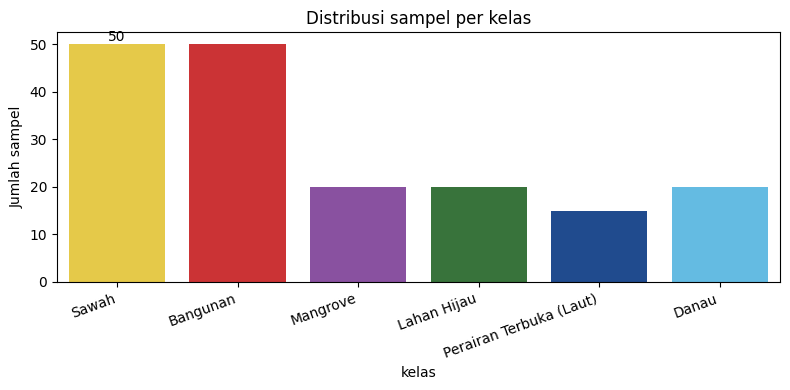

In [7]:
jml = df["kelas"].value_counts().reindex(NAMA_KELAS)
print("Jumlah kelas :", df["kelas"].nunique())
print("Jumlah data  :", len(df))
display(jml.to_frame("jumlah sampel"))

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=jml.index, y=jml.values, palette=[WARNA_KELAS[k] for k in jml.index])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=20, ha="right"); plt.ylabel("Jumlah sampel"); plt.title("Distribusi sampel per kelas")
plt.tight_layout(); plt.show()

In [8]:
display(df[FITUR_SEMUA].describe().T.round(4))
print("\nRata-rata fitur per kelas:")
display(df.groupby("kelas")[FITUR_SEMUA].mean().reindex(NAMA_KELAS).round(3))

,count,mean,std,min,25%,50%,75%,max
B2,175.0,0.0602,0.0319,0.0177,0.0364,0.0509,0.0801,0.1912
B3,175.0,0.0798,0.0330,0.0207,0.0561,0.0738,0.0978,0.2008
B4,175.0,0.0742,0.0505,0.0107,0.0319,0.0610,0.1044,0.2448
B5,175.0,0.1113,0.0489,0.0073,0.0866,0.1192,0.1509,0.2155
B6,175.0,0.1823,0.0937,0.0000,0.1507,0.1955,0.2535,0.3897
B7,175.0,0.2084,0.1140,0.0000,0.1661,0.2233,0.2897,0.4526
B8,175.0,0.2065,0.1153,0.0000,0.1556,0.2216,0.2931,0.4572
B8A,175.0,0.2257,0.1250,0.0000,0.1797,0.2392,0.3208,0.4996
B11,175.0,0.1703,0.0942,0.0065,0.1193,0.1884,0.2437,0.3126
B12,175.0,0.1197,0.0889,0.0046,0.0484,0.1045,0.1834,0.3046



Rata-rata fitur per kelas:


,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
kelas,,,,,,,,,,,,,,,,,,
Sawah,0.052,0.080,0.073,0.130,0.234,0.269,0.268,0.293,0.207,0.117,0.568,-0.534,-0.435,-0.131,0.345,0.369,0.345,-0.071
Bangunan,0.102,0.119,0.140,0.158,0.174,0.182,0.184,0.199,0.258,0.239,0.142,-0.217,-0.369,0.166,0.074,0.089,0.081,0.164
Mangrove,0.032,0.058,0.031,0.100,0.257,0.303,0.298,0.326,0.115,0.047,0.801,-0.661,-0.321,-0.437,0.486,0.530,0.478,-0.382
Lahan Hijau,0.035,0.057,0.036,0.097,0.279,0.349,0.343,0.379,0.183,0.087,0.806,-0.712,-0.525,-0.300,0.552,0.590,0.519,-0.265
Perairan Terbuka (Laut),0.054,0.052,0.029,0.028,0.020,0.020,0.016,0.017,0.011,0.009,-0.246,0.482,0.593,-0.172,-0.237,-0.042,-0.034,-0.286
Danau,0.034,0.046,0.028,0.036,0.026,0.028,0.024,0.027,0.023,0.015,-0.344,0.528,0.480,0.090,-0.423,-0.017,-0.019,-0.074


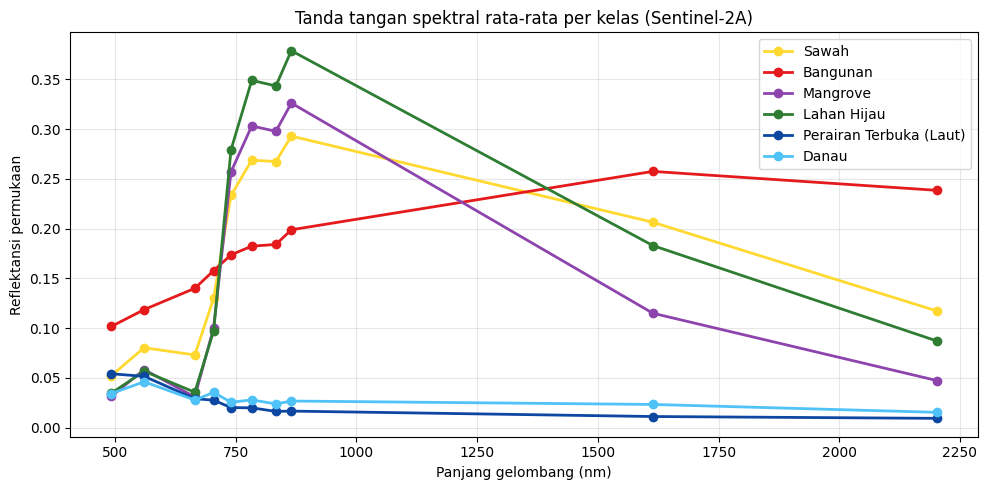

In [9]:
panjang_gelombang = [492, 560, 665, 704, 740, 783, 833, 865, 1614, 2202]
rata = df.groupby("kelas")[BAND_ASLI].mean().reindex(NAMA_KELAS)

plt.figure(figsize=(10, 5))
for k in NAMA_KELAS:
    plt.plot(panjang_gelombang, rata.loc[k].values, marker="o", lw=2, label=k, color=WARNA_KELAS[k])
plt.xlabel("Panjang gelombang (nm)"); plt.ylabel("Reflektansi permukaan")
plt.title("Tanda tangan spektral rata-rata per kelas (Sentinel-2A)")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

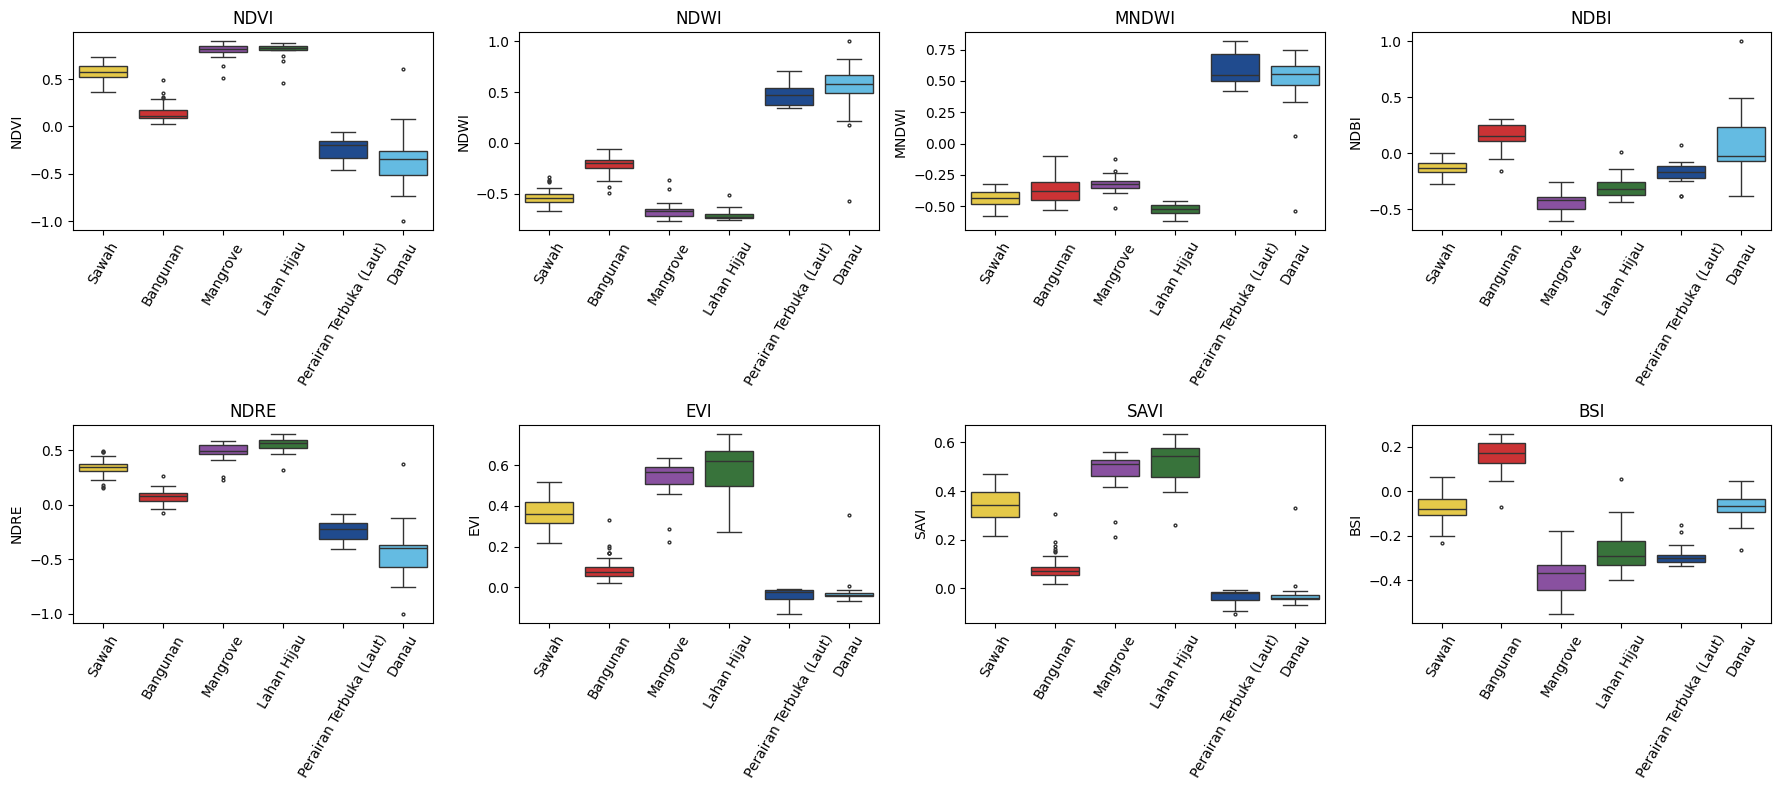

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), INDEKS):
    sns.boxplot(data=df, x="kelas", y=f, order=NAMA_KELAS, palette=WARNA_KELAS, ax=ax, fliersize=2)
    ax.set_title(f); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

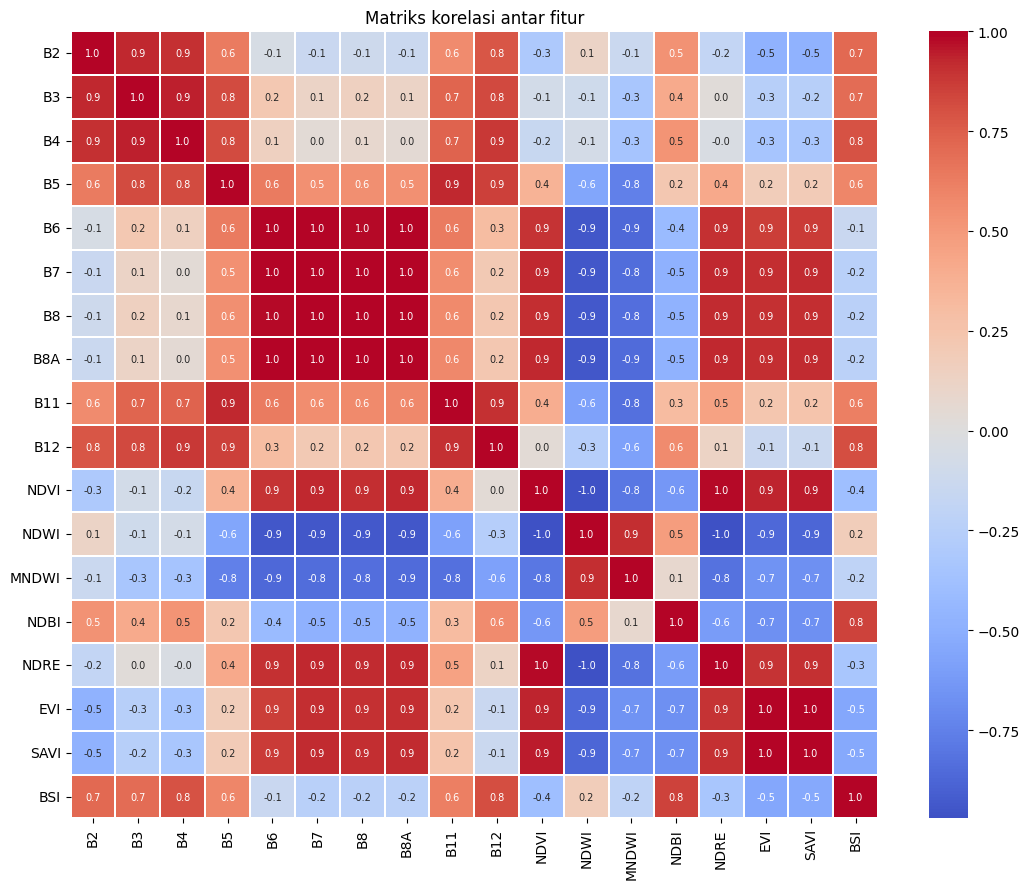

In [11]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[FITUR_SEMUA].corr(), cmap="coolwarm", center=0, annot=True, fmt=".1f",
            annot_kws={"size": 7}, linewidths=.3)
plt.title("Matriks korelasi antar fitur"); plt.tight_layout(); plt.show()

In [12]:
UKURAN_TEST = 0.20
X = df[FITUR_SEMUA]
y = df["kelas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=UKURAN_TEST, stratify=y, random_state=SEED)

tabel_split = pd.DataFrame({
    "Total":    y.value_counts(),
    "Training": y_train.value_counts(),
    "Testing":  y_test.value_counts(),
}).reindex(NAMA_KELAS)
tabel_split.loc["TOTAL"] = tabel_split.sum()
print(f"Jumlah kelas        : {y.nunique()}")
print(f"Jumlah data training: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Jumlah data testing : {len(X_test)} ({len(X_test)/len(X):.0%})")
display(tabel_split.astype(int))

Jumlah kelas        : 6
Jumlah data training: 140 (80%)
Jumlah data testing : 35 (20%)


,Total,Training,Testing
kelas,,,
Sawah,50,40,10
Bangunan,50,40,10
Mangrove,20,16,4
Lahan Hijau,20,16,4
Perairan Terbuka (Laut),15,12,3
Danau,20,16,4
TOTAL,175,140,35


Akurasi training : 0.9000
Akurasi testing  : 0.8571
Kappa (testing)  : 0.8209
F1 macro (testing): 0.7755

                         precision    recall  f1-score   support

                  Sawah       1.00      0.90      0.95        10
               Bangunan       1.00      1.00      1.00        10
               Mangrove       0.80      1.00      0.89         4
            Lahan Hijau       0.75      0.75      0.75         4
Perairan Terbuka (Laut)       0.50      1.00      0.67         3
                  Danau       1.00      0.25      0.40         4

               accuracy                           0.86        35
              macro avg       0.84      0.82      0.78        35
           weighted avg       0.91      0.86      0.85        35



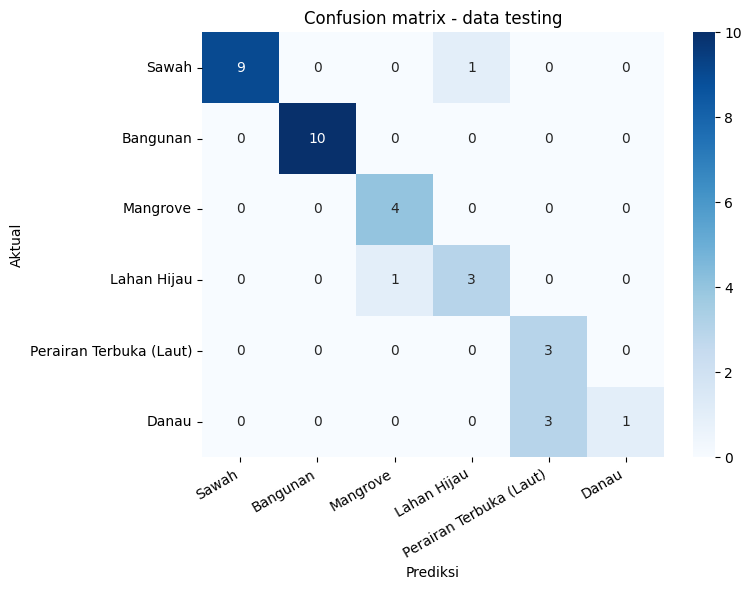

In [13]:
model = GaussianNB()
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test  = model.predict(X_test)

print(f"Akurasi training : {accuracy_score(y_train, pred_train):.4f}")
print(f"Akurasi testing  : {accuracy_score(y_test,  pred_test):.4f}")
print(f"Kappa (testing)  : {cohen_kappa_score(y_test, pred_test):.4f}")
print(f"F1 macro (testing): {f1_score(y_test, pred_test, average='macro'):.4f}\n")
print(classification_report(y_test, pred_test, labels=NAMA_KELAS, zero_division=0))

cm = confusion_matrix(y_test, pred_test, labels=NAMA_KELAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion matrix - data testing")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [14]:
hasil_rasio = []
for ts in [0.10, 0.20, 0.30, 0.40]:
    skor = []
    for s in range(30):
        Xa, Xb, ya, yb = train_test_split(X, y, test_size=ts, stratify=y, random_state=s)
        skor.append(accuracy_score(yb, GaussianNB().fit(Xa, ya).predict(Xb)))
    hasil_rasio.append({"Rasio train:test": f"{int((1-ts)*100)}:{int(ts*100)}",
                        "n training": int(len(y)*(1-ts)), "n testing": int(round(len(y)*ts)),
                        "Akurasi rata-rata": np.mean(skor), "Std": np.std(skor)})
tab_rasio = pd.DataFrame(hasil_rasio)
display(tab_rasio.round(4))

,Rasio train:test,n training,n testing,Akurasi rata-rata,Std
0,90:10,157,18,0.8722,0.0540
1,80:20,140,35,0.8790,0.0428
2,70:30,122,52,0.8811,0.0355
3,60:40,105,70,0.8814,0.0358


In [15]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

skenario_fitur = {
    "A. 4 band 10 m (B2,B3,B4,B8)":            ["B2", "B3", "B4", "B8"],
    "B. 10 band Sentinel-2A":                  BAND_ASLI,
    "C. 8 indeks spektral":                    INDEKS,
    "D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)": ["NDVI", "MNDWI", "NDBI", "BSI"],
    "E. Band + indeks (18 fitur)":             FITUR_SEMUA,
}
hasil_fitur = []
for nama, cols in skenario_fitur.items():
    s = cross_val_score(GaussianNB(), df[cols], y, cv=cv, scoring="accuracy")
    f = cross_val_score(GaussianNB(), df[cols], y, cv=cv, scoring="f1_macro")
    hasil_fitur.append({"Skenario": nama, "Jumlah fitur": len(cols),
                        "Akurasi CV": s.mean(), "Std": s.std(), "F1 macro CV": f.mean()})
tab_fitur = pd.DataFrame(hasil_fitur).sort_values("Akurasi CV", ascending=False).reset_index(drop=True)
display(tab_fitur.round(4))

FITUR_FINAL_NAMA = tab_fitur.loc[0, "Skenario"]
FITUR_FINAL = skenario_fitur[FITUR_FINAL_NAMA]
print("\nSkenario fitur terbaik:", FITUR_FINAL_NAMA, f"({len(FITUR_FINAL)} fitur)")

,Skenario,Jumlah fitur,Akurasi CV,Std,F1 macro CV
0,"D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)",4,0.9074,0.0426,0.8872
1,C. 8 indeks spektral,8,0.8914,0.0428,0.8705
2,E. Band + indeks (18 fitur),18,0.8823,0.0336,0.8379
3,B. 10 band Sentinel-2A,10,0.8257,0.0421,0.7278
4,"A. 4 band 10 m (B2,B3,B4,B8)",4,0.7629,0.0465,0.6725



Skenario fitur terbaik: D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI) (4 fitur)


,var_smoothing,Akurasi CV,Std
0,1e-12,0.9074,0.0426
1,1e-11,0.9074,0.0426
2,1e-10,0.9074,0.0426
3,1e-09,0.9074,0.0426
4,1e-08,0.9074,0.0426
5,1e-07,0.9074,0.0426
6,1e-06,0.9074,0.0426
7,1e-05,0.9074,0.0426
8,1e-04,0.9074,0.0426
9,1e-03,0.9063,0.0428


var_smoothing terbaik: 1.00e-12 | akurasi CV: 0.9074


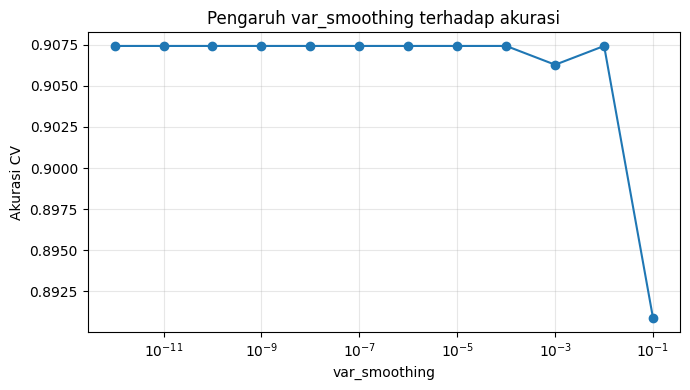

In [16]:
grid = GridSearchCV(GaussianNB(), {"var_smoothing": np.logspace(-12, -1, 12)},
                    cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(df[FITUR_FINAL], y)

tab_vs = (pd.DataFrame(grid.cv_results_)[["param_var_smoothing", "mean_test_score", "std_test_score"]]
          .rename(columns={"param_var_smoothing": "var_smoothing",
                           "mean_test_score": "Akurasi CV", "std_test_score": "Std"}))
tab_vs["var_smoothing"] = tab_vs["var_smoothing"].astype(float)
display(tab_vs.assign(var_smoothing=tab_vs["var_smoothing"].map(lambda v: f"{v:.0e}")).round(4))
VAR_SMOOTH = float(grid.best_params_["var_smoothing"])
print(f"var_smoothing terbaik: {VAR_SMOOTH:.2e} | akurasi CV: {grid.best_score_:.4f}")

plt.figure(figsize=(7, 4))
plt.semilogx(tab_vs["var_smoothing"].astype(float), tab_vs["Akurasi CV"], marker="o")
plt.xlabel("var_smoothing"); plt.ylabel("Akurasi CV"); plt.grid(alpha=.3)
plt.title("Pengaruh var_smoothing terhadap akurasi"); plt.tight_layout(); plt.show()

Akurasi testing model final : 0.9143
Kappa                       : 0.8922
F1 macro                    : 0.9134

                         precision    recall  f1-score   support

                  Sawah       1.00      0.80      0.89        10
               Bangunan       0.91      1.00      0.95        10
               Mangrove       0.80      1.00      0.89         4
            Lahan Hijau       0.75      0.75      0.75         4
Perairan Terbuka (Laut)       1.00      1.00      1.00         3
                  Danau       1.00      1.00      1.00         4

               accuracy                           0.91        35
              macro avg       0.91      0.92      0.91        35
           weighted avg       0.92      0.91      0.91        35



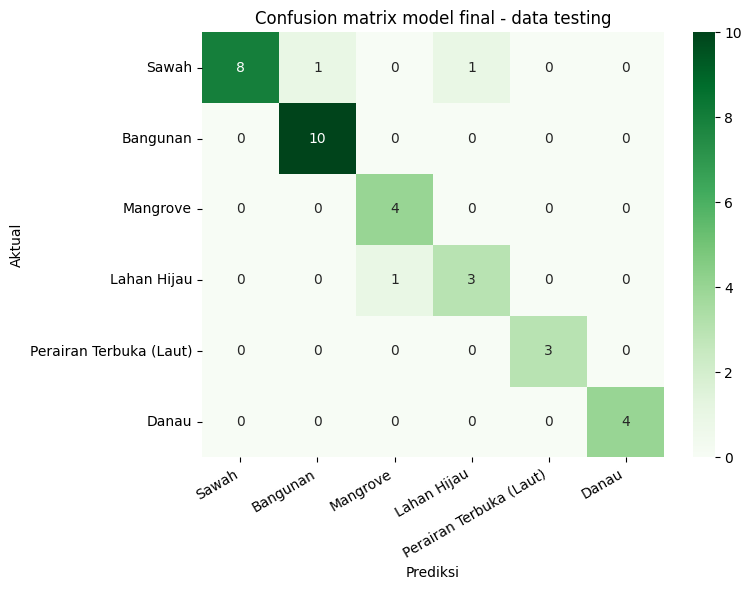

In [17]:
model_final = GaussianNB(var_smoothing=VAR_SMOOTH).fit(X_train[FITUR_FINAL], y_train)
pred_final = model_final.predict(X_test[FITUR_FINAL])

AKURASI_FINAL = accuracy_score(y_test, pred_final)
KAPPA_FINAL   = cohen_kappa_score(y_test, pred_final)
F1_FINAL      = f1_score(y_test, pred_final, average="macro")

print(f"Akurasi testing model final : {AKURASI_FINAL:.4f}")
print(f"Kappa                       : {KAPPA_FINAL:.4f}")
print(f"F1 macro                    : {F1_FINAL:.4f}\n")
print(classification_report(y_test, pred_final, labels=NAMA_KELAS, zero_division=0))

cm = confusion_matrix(y_test, pred_final, labels=NAMA_KELAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion matrix model final - data testing")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [18]:
JATIM       = [111.0, -8.85, 114.65, -6.75]   # [barat, selatan, timur, utara] - seluruh Jawa Timur
AOI         = JATIM                           # ganti untuk area yang lebih kecil
SKALA_PETA  = 250                             # meter per piksel (provinsi: 250; area kecil: 10-60)
TILE_PX     = 500                             # ukuran ubin (piksel) per permintaan
ULANGI_PETA = False                           # True: paksa unduh & prediksi ulang
FILE_PETA   = "label_peta.npz"

# Latih ulang model final dengan seluruh data berlabel
model_peta = GaussianNB(var_smoothing=VAR_SMOOTH).fit(df[FITUR_FINAL], df["kelas"])

def hex_ke_rgb(h):
    h = h.lstrip("#"); return [int(h[i:i+2], 16) for i in (0, 2, 4)]

def klasifikasi_aoi(aoi, skala, tile_px, model, fitur):
    """Mengklasifikasi AOI per ubin. Hasil: raster kode kelas (indeks NAMA_KELAS; -1 = tanpa data)."""
    barat, selatan, timur, utara = aoi
    dx = skala / 111320.0                                  # meter -> derajat
    W = int(math.ceil((timur - barat) / dx))
    H = int(math.ceil((utara - selatan) / dx))
    n_tile = math.ceil(H / tile_px) * math.ceil(W / tile_px)
    print(f"Raster {W} x {H} piksel ({W*H:,} piksel), dibagi menjadi {n_tile} ubin")

    kode = {nama: i for i, nama in enumerate(NAMA_KELAS)}
    label = np.full((H, W), -1, dtype=np.int8)
    n, gagal = 0, []
    for r0 in range(0, H, tile_px):
        for c0 in range(0, W, tile_px):
            r1, c1 = min(r0 + tile_px, H), min(c0 + tile_px, W)
            bbox = BBox([barat + c0*dx, utara - r1*dx, barat + c1*dx, utara - r0*dx], crs=CRS.WGS84)
            arr = None
            for percobaan in range(3):
                try:
                    arr = ambil_median(bbox, (c1 - c0, r1 - r0)); break
                except Exception as e:
                    if percobaan == 2: gagal.append((r0, c0, str(e)[:100]))
                    time.sleep(5)
            n += 1
            print(f"\rUbin {n}/{n_tile}", end="")
            if arr is None:
                continue
            h, w = arr.shape[:2]
            d = tambah_indeks(pd.DataFrame(arr.reshape(-1, len(BAND_ASLI)), columns=BAND_ASLI))
            d = d.replace([np.inf, -np.inf], np.nan)
            valid = d[FITUR_SEMUA].notna().all(axis=1).values
            if valid.any():
                pred = model.predict(d.loc[valid, fitur])
                kk = np.full(h * w, -1, dtype=np.int8)
                kk[valid] = [kode[p] for p in pred]
                label[r0:r0+h, c0:c0+w] = kk.reshape(h, w)
    print()
    if gagal:
        print(f"PERINGATAN: {len(gagal)} ubin gagal diunduh dan dibiarkan kosong. Contoh galat: {gagal[0][2]}")
    batas = [[utara - H*dx, barat], [utara, barat + W*dx]]  # [[selatan, barat], [utara, timur]]
    return label, batas

def muat_cache():
    if os.path.exists(FILE_PETA) and not ULANGI_PETA:
        z = np.load(FILE_PETA, allow_pickle=True)
        if (np.allclose(z["aoi"], AOI) and float(z["skala"]) == SKALA_PETA
                and list(z["fitur"]) == list(FITUR_FINAL)):
            return z["label"], z["batas"].tolist()
    return None

hasil_cache = muat_cache()
if hasil_cache is not None:
    label_peta, batas_peta = hasil_cache
    print("Hasil klasifikasi dimuat dari", FILE_PETA)
else:
    label_peta, batas_peta = klasifikasi_aoi(AOI, SKALA_PETA, TILE_PX, model_peta, FITUR_FINAL)
    np.savez_compressed(FILE_PETA, label=label_peta, batas=np.array(batas_peta), aoi=np.array(AOI),
                        skala=SKALA_PETA, fitur=np.array(FITUR_FINAL))
print("Ukuran raster hasil:", label_peta.shape)

Hasil klasifikasi dimuat dari label_peta.npz
Ukuran raster hasil: (936, 1626)


In [19]:
# Ubah kode kelas -> gambar RGBA (piksel tanpa data/awan dibuat transparan)
H, W = label_peta.shape
rgba = np.zeros((H, W, 4), dtype=np.uint8)
for idx, nama in enumerate(NAMA_KELAS):
    rgba[label_peta == idx] = hex_ke_rgb(WARNA_KELAS[nama]) + [255]

# Statistik luas hasil klasifikasi pada AOI
lat_tengah = (AOI[1] + AOI[3]) / 2
luas_piksel_ha = (SKALA_PETA * SKALA_PETA * math.cos(math.radians(lat_tengah))) / 10_000
jumlah = np.bincount(label_peta[label_peta >= 0].astype(int), minlength=len(NAMA_KELAS))
tab_luas = pd.DataFrame({"Jumlah piksel": jumlah}, index=NAMA_KELAS)
tab_luas["Luas (ha)"] = (tab_luas["Jumlah piksel"] * luas_piksel_ha).round(1)
tab_luas["Persentase (%)"] = (100 * tab_luas["Jumlah piksel"] / max(tab_luas["Jumlah piksel"].sum(), 1)).round(2)
print(f"Piksel tanpa data: {(label_peta < 0).sum():,} dari {label_peta.size:,}")
display(tab_luas)

Piksel tanpa data: 78 dari 1,521,936


,Jumlah piksel,Luas (ha),Persentase (%)
Sawah,456450,2826417.8,29.99
Bangunan,53978,334241.2,3.55
Mangrove,31451,194750.1,2.07
Lahan Hijau,308194,1908390.9,20.25
Perairan Terbuka (Laut),265195,1642133.6,17.43
Danau,406590,2517676.0,26.72


Peta disimpan: hasil_klasifikasi_naive_bayes.html (dapat ditanam di web statis lewat <iframe>)



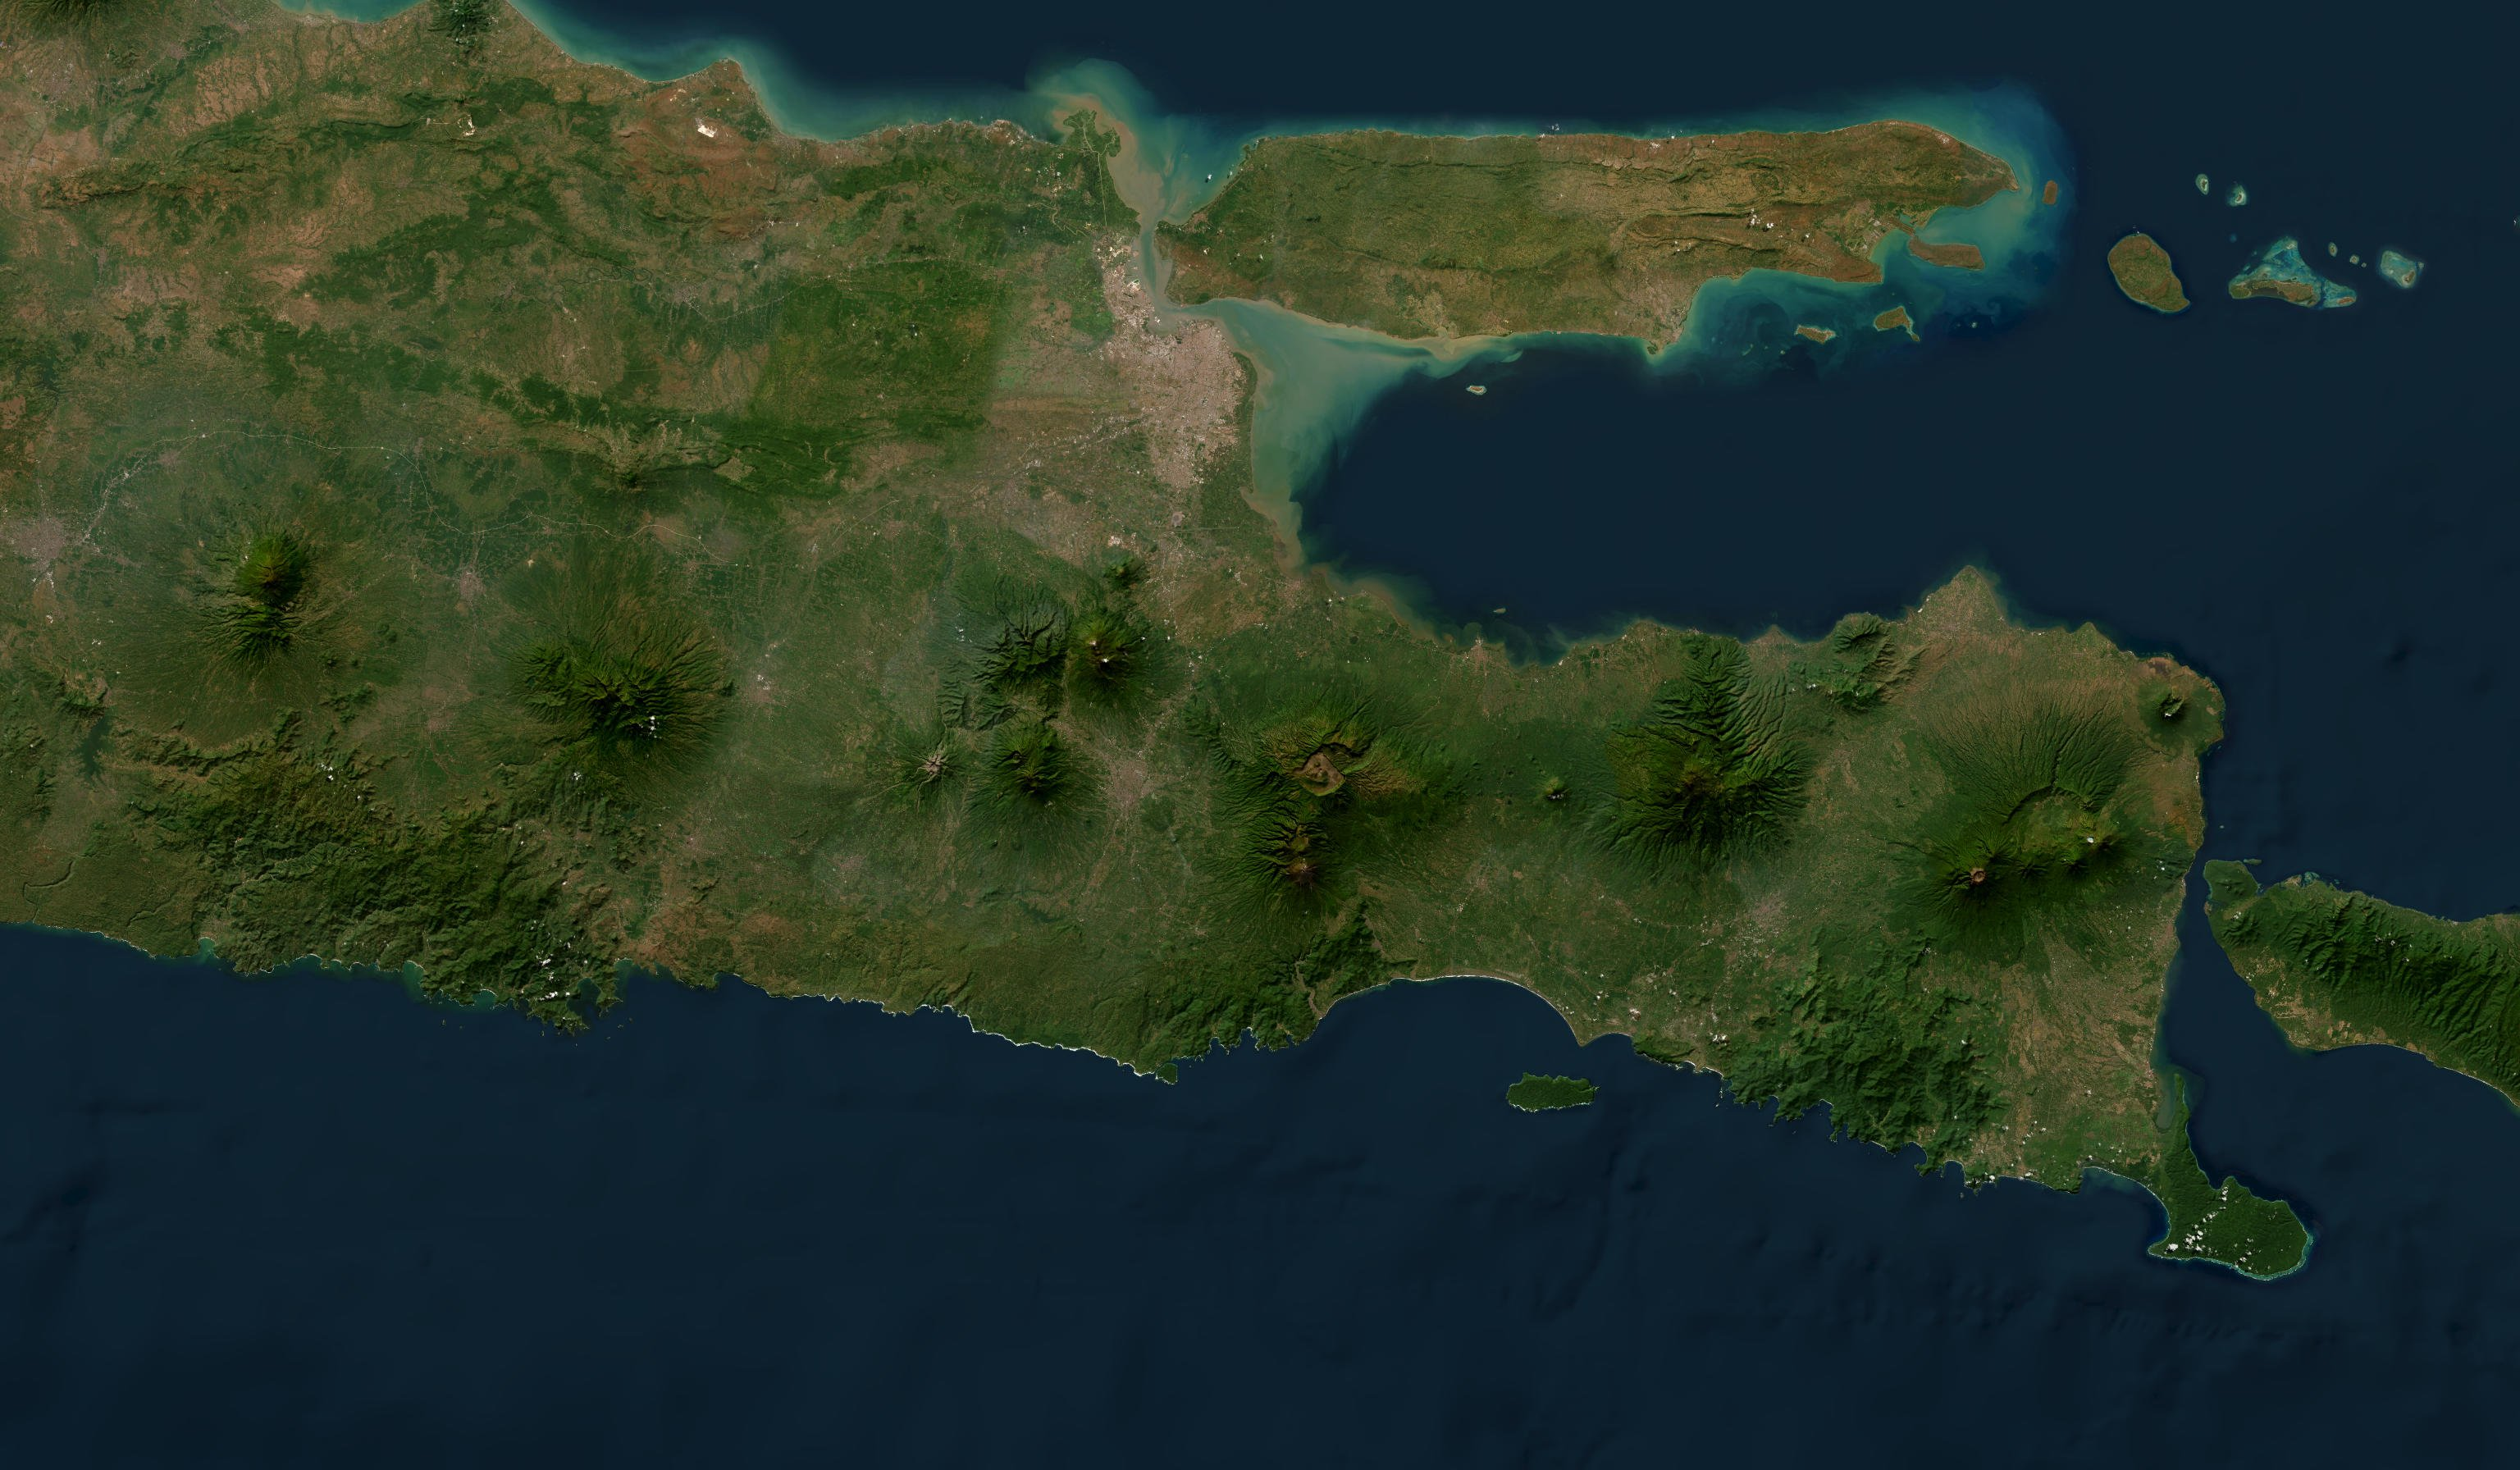
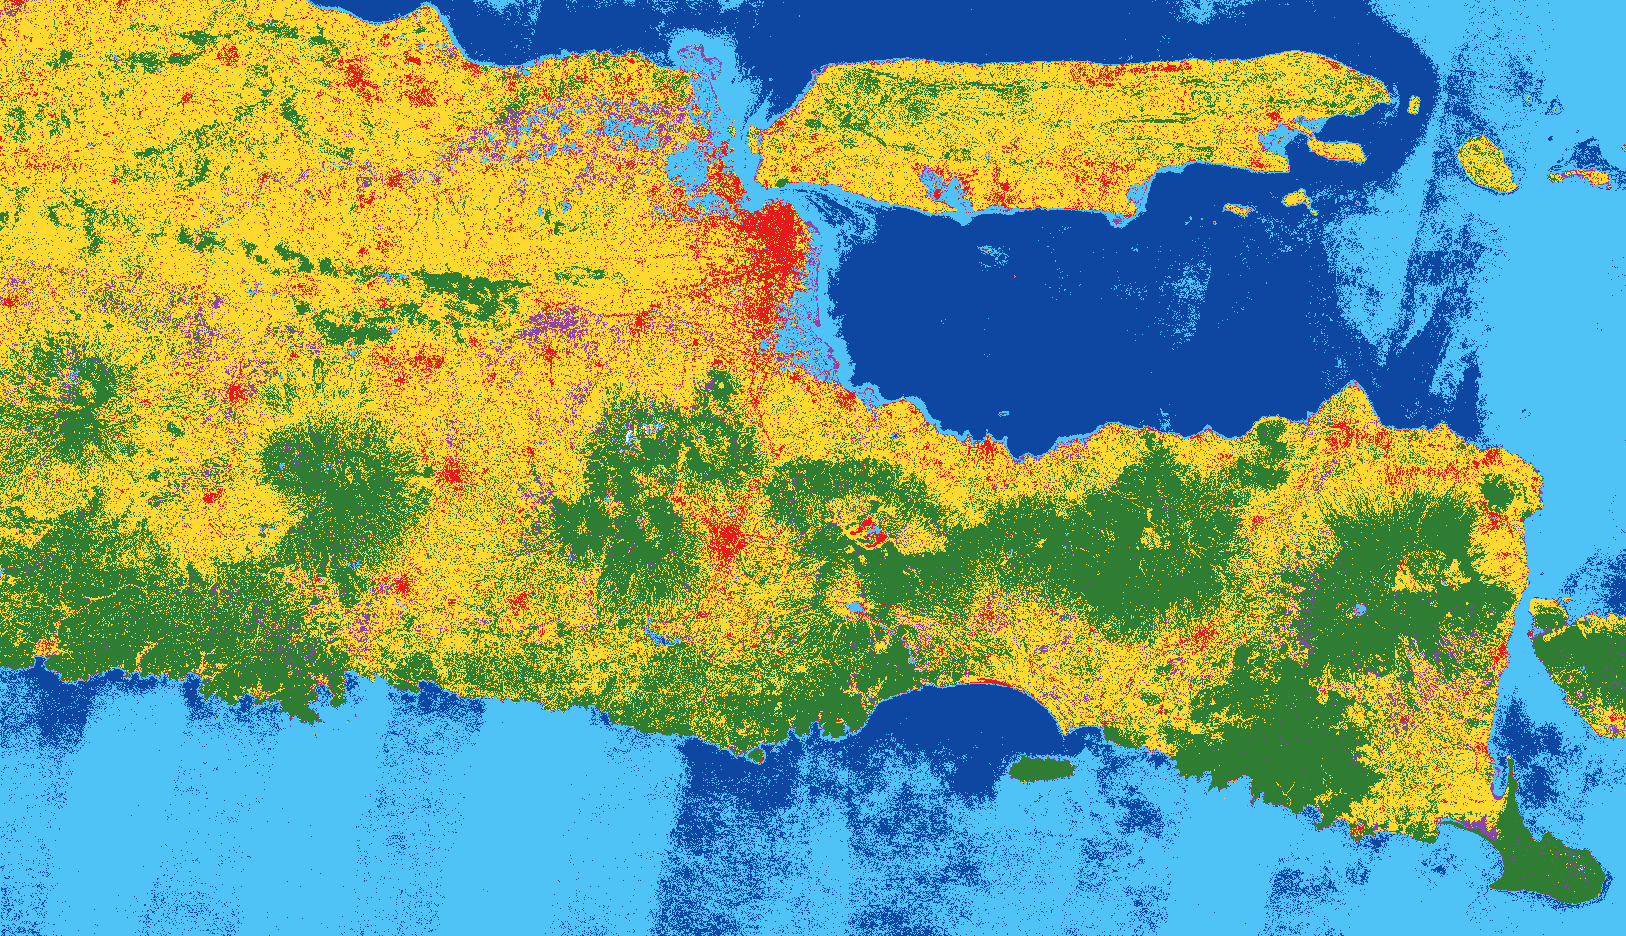

In [20]:
import math, io, requests
import folium
from folium.raster_layers import ImageOverlay
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

# --- Unduh citra satelit Esri untuk AOI, lalu tanam di peta ---
def ambil_satelit(aoi, z=10):
    n = 2 ** z
    def xy(lon, lat):
        x = (lon + 180) / 360 * n
        y = (1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n
        return x, y
    def lon_dari_x(x): return x / n * 360 - 180
    def lat_dari_y(y): return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))

    x0, y0 = xy(aoi[0], aoi[3])
    x1, y1 = xy(aoi[2], aoi[1])
    xa, xb, ya, yb = int(x0), int(x1), int(y0), int(y1)

    mosaik = Image.new("RGB", ((xb - xa + 1) * 256, (yb - ya + 1) * 256), (200, 200, 200))
    url = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"

    def unduh(xy_):
        x, y = xy_
        try:
            r = requests.get(url.format(z=z, x=x, y=y), headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
            return x, y, Image.open(io.BytesIO(r.content)).convert("RGB")
        except Exception:
            return x, y, None

    ubin = [(x, y) for x in range(xa, xb + 1) for y in range(ya, yb + 1)]
    with ThreadPoolExecutor(max_workers=8) as ex:
        for x, y, im in ex.map(unduh, ubin):
            if im is not None:
                mosaik.paste(im, ((x - xa) * 256, (y - ya) * 256))

    batas = [[lat_dari_y(yb + 1), lon_dari_x(xa)], [lat_dari_y(ya), lon_dari_x(xb + 1)]]
    return mosaik, batas

mosaik, batas_satelit = ambil_satelit(AOI, z=10)   # z=9 lebih ringan, z=11 lebih tajam
mosaik.save("satelit_aoi.jpeg", quality=85)

# --- Peta ---
pusat = [(AOI[1] + AOI[3]) / 2, (AOI[0] + AOI[2]) / 2]
peta = folium.Map(location=pusat, zoom_start=8, tiles=None, control_scale=True)

# Basemap online (untuk area di luar AOI saat dibuka di browser)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics",
    name="Esri Satellite (online)", max_zoom=19, overlay=False, control=True,
).add_to(peta)
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attr="Google Hybrid", name="Google Hybrid (dengan label)",
    max_zoom=20, overlay=False, control=True, show=False,
).add_to(peta)

# LAYER BAWAH: satelit yang ditanam di dalam peta (selalu tampil, termasuk di notebook)
ImageOverlay(image="satelit_aoi.jpeg", bounds=batas_satelit, opacity=1,
             name="Satelit (tertanam)", interactive=False, zindex=1).add_to(peta)

# LAYER ATAS: hasil klasifikasi
ImageOverlay(image=rgba, bounds=batas_peta, opacity=0.65,
             name="Hasil Klasifikasi Naive Bayes", interactive=False, zindex=5).add_to(peta)

# --- Titik sampel per kelas (default disembunyikan) ---
for nama in NAMA_KELAS:
    grup = folium.FeatureGroup(name=f"Sampel: {nama}", show=False)
    for _, r in df[df["kelas"] == nama].iterrows():
        folium.CircleMarker([r.lat, r.lon], radius=4, color="white", weight=1,
                            fill=True, fill_color=WARNA_KELAS[nama], fill_opacity=1,
                            popup=f"{nama} (lon {r.lon:.4f}, lat {r.lat:.4f})").add_to(grup)
    grup.add_to(peta)

# --- Kotak batas AOI ---
grup_aoi = folium.FeatureGroup(name="Batas area studi")
folium.Rectangle([[AOI[1], AOI[0]], [AOI[3], AOI[2]]], color="white", weight=1.5,
                 fill=False, dash_array="6").add_to(grup_aoi)
grup_aoi.add_to(peta)

# --- Legenda ---
item = "".join(
    f'<div style="margin:2px 0"><span style="display:inline-block;width:14px;height:14px;'
    f'background:{WARNA_KELAS[k]};border:1px solid #333;margin-right:6px;vertical-align:middle"></span>{k}</div>'
    for k in NAMA_KELAS)
legenda = (f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
           f'padding:10px 12px;border:1px solid #888;border-radius:6px;font:13px Arial;">'
           f'<b>Legenda LULC</b><br>{item}</div>')
peta.get_root().html.add_child(folium.Element(legenda))

folium.LayerControl(collapsed=False).add_to(peta)
peta.fit_bounds([[AOI[1], AOI[0]], [AOI[3], AOI[2]]])

peta.save("hasil_klasifikasi_naive_bayes.html")
print("Peta disimpan: hasil_klasifikasi_naive_bayes.html (dapat ditanam di web statis lewat <iframe>)")
peta

In [21]:
terbaik_rasio = tab_rasio.sort_values("Akurasi rata-rata", ascending=False).iloc[0]
kelas_lemah = (pd.Series(f1_score(y_test, pred_final, labels=NAMA_KELAS, average=None, zero_division=0),
                         index=NAMA_KELAS).sort_values())
display(Markdown(f"""
**Ringkasan hasil**

* **Data:** {len(df)} sampel dari {df['kelas'].nunique()} kelas ({', '.join(f'{k}: {v}' for k, v in jml.items())}).
  Pembagian 80:20 menghasilkan **{len(X_train)} data training** dan **{len(X_test)} data testing**.
* **Fitur:** 10 band Sentinel-2A + 8 indeks spektral (NDVI, NDWI, MNDWI, NDBI, NDRE, EVI, SAVI, BSI).
* **Model:** Gaussian Naive Bayes (`var_smoothing` = {VAR_SMOOTH:.2e}) dengan skenario fitur terbaik
  **{FITUR_FINAL_NAMA}**.
* **Kinerja model final (data testing):** akurasi **{AKURASI_FINAL:.2%}**, Kappa **{KAPPA_FINAL:.3f}**,
  F1 macro **{F1_FINAL:.3f}**.
* **Eksperimen rasio split:** rata-rata akurasi tertinggi pada rasio **{terbaik_rasio['Rasio train:test']}**
  ({terbaik_rasio['Akurasi rata-rata']:.2%}).
* **Kelas dengan F1 terendah:** **{kelas_lemah.index[0]}** ({kelas_lemah.iloc[0]:.2f}),
  lihat *confusion matrix* untuk melihat kelas mana yang tertukar.
* **Peta:** hasil klasifikasi ditampilkan pada `hasil_klasifikasi_naive_bayes.html` di atas citra Google Satellite.
"""))


**Ringkasan hasil**

* **Data:** 175 sampel dari 6 kelas (Sawah: 50, Bangunan: 50, Mangrove: 20, Lahan Hijau: 20, Perairan Terbuka (Laut): 15, Danau: 20).
  Pembagian 80:20 menghasilkan **140 data training** dan **35 data testing**.
* **Fitur:** 10 band Sentinel-2A + 8 indeks spektral (NDVI, NDWI, MNDWI, NDBI, NDRE, EVI, SAVI, BSI).
* **Model:** Gaussian Naive Bayes (`var_smoothing` = 1.00e-12) dengan skenario fitur terbaik
  **D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)**.
* **Kinerja model final (data testing):** akurasi **91.43%**, Kappa **0.892**,
  F1 macro **0.913**.
* **Eksperimen rasio split:** rata-rata akurasi tertinggi pada rasio **60:40**
  (88.14%).
* **Kelas dengan F1 terendah:** **Lahan Hijau** (0.75),
  lihat *confusion matrix* untuk melihat kelas mana yang tertukar.
* **Peta:** hasil klasifikasi ditampilkan pada `hasil_klasifikasi_naive_bayes.html` di atas citra Google Satellite.
